# Semi-Supervised Learning

## Aim
To understand the fundamentals of Semi-Supervised Learning and implement a Self-Training Classifier using the Breast Cancer dataset.

### Topics Covered
- Introduction to Semi-Supervised Learning
- Labeled and Unlabeled Data
- Workflow
- Self-Training Classifier
- Practical Implementation

# What is Semi-Supervised Learning?

Semi-Supervised Learning is a type of Machine Learning that uses **both labeled and unlabeled data** for training.

A small portion of the data is labeled, while the remaining data is unlabeled. The model learns from both to improve prediction accuracy.

It combines the strengths of supervised and unsupervised learning.


# Types of Machine Learning

| Supervised Learning | Unsupervised Learning | Semi-Supervised Learning |
|---------------------|-----------------------|--------------------------|
| Uses labeled data | Uses unlabeled data | Uses both labeled and unlabeled data |
| Predicts known outputs | Finds hidden patterns | Improves learning using limited labels |
| Example: Email Spam Detection | Example: Customer Segmentation | Example: Medical Image Classification |


# Why Semi-Supervised Learning?

Labeling large datasets is expensive and time-consuming.

Semi-Supervised Learning helps by:
- Reducing labeling effort.
- Improving model accuracy.
- Making use of abundant unlabeled data.
- Lowering the cost of data annotation.

# Real-World Applications

- Medical diagnosis
- Image classification
- Speech recognition
- Text classification
- Fraud detection
- Face recognition
- Web page classification
- Document categorization

# How Semi-Supervised Learning Works

1. Start with a small labeled dataset.
2. Train an initial model.
3. Predict labels for unlabeled data.
4. Select high-confidence predictions.
5. Add pseudo-labeled data to the training set.
6. Retrain the model.
7. Repeat until satisfactory performance is achieved.


# Workflow Diagram

Labeled Data

      │
      ▼

 Train Initial Model

      │
      ▼
Predict Unlabeled Data

      │
      ▼
Generate Pseudo Labels

      │
      ▼
Combine Data

      │
      ▼
Retrain Model

      │
      ▼
 Improved Performance

### Steps
1. Load the dataset.
2. Split the data into training and testing sets.
3. Simulate limited labeled data.
4. Train a Self-Training Classifier.
5. Evaluate the model.

In [2]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Loaded Successfully!")
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


# Display dataset information

print("Feature Names:\n")
print(data.feature_names)

print("\nTarget Names:")
print(data.target_names)

Dataset Loaded Successfully!
Features Shape: (569, 30)
Target Shape: (569,)
Feature Names:

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']


In [3]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 398
Testing Samples : 171


# Simulating Unlabeled Data

Semi-Supervised Learning assumes that only a small portion of the training data is labeled.

We will randomly remove labels from 70% of the training samples by assigning them a value of **-1**.

In [6]:
# Create unlabeled samples

rng = np.random.RandomState(42)

y_train_semi = np.copy(y_train)

random_unlabeled = rng.rand(len(y_train)) < 0.7

y_train_semi[random_unlabeled] = -1

print("Number of Unlabeled Samples:", np.sum(y_train_semi == -1))

Number of Unlabeled Samples: 280


# Creating the Self-Training Classifier

The Self-Training Classifier works by:

- Training on labeled data.
- Predicting labels for unlabeled data.
- Selecting high-confidence predictions.
- Retraining the model using both labeled and pseudo-labeled data.

In [7]:
# Create base classifier

base_classifier = SVC(
    probability=True,
    gamma="scale",
    random_state=42
)

self_training_model = SelfTrainingClassifier(base_classifier)

# Train the model

self_training_model.fit(X_train, y_train_semi)

print("Model Training Completed!")

# Make predictions

y_pred = self_training_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2),"%")

Model Training Completed!
Accuracy: 92.98 %


In [8]:
# Display first few predictions

print("Actual Labels:")
print(y_test[:10])

print("\nPredicted Labels:")
print(y_pred[:10])

Actual Labels:
[1 0 0 1 1 0 0 0 1 1]

Predicted Labels:
[1 0 0 1 1 0 0 0 1 1]


# Model Evaluation

After training the Self-Training Classifier, we evaluate its performance using:
- Accuracy
- Confusion Matrix
- Classification Report

In [9]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[ 55   8]
 [  4 104]]


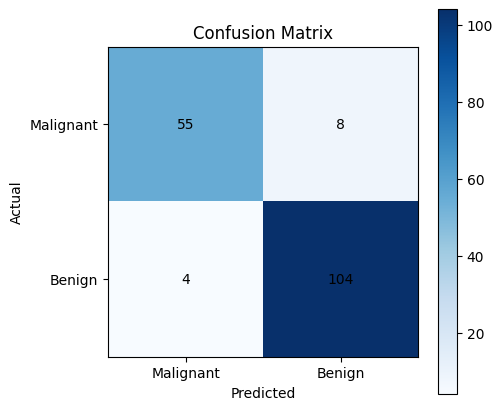

In [10]:
# Visualize Confusion Matrix

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Malignant", "Benign"])
plt.yticks([0,1], ["Malignant", "Benign"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")

plt.show()

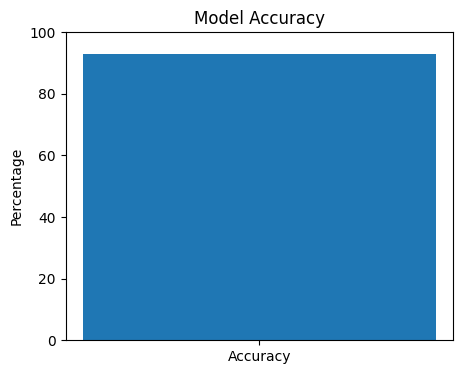

In [11]:
# Accuracy Visualization

labels = ["Accuracy"]
values = [accuracy * 100]

plt.figure(figsize=(5,4))
plt.bar(labels, values)
plt.ylim(0,100)
plt.ylabel("Percentage")
plt.title("Model Accuracy")
plt.show()